In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import LinAlgError
from statsmodels.stats.multitest import multipletests

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)

In [3]:
MODE = 'PDE'

# Load data based on the mode
if MODE == 'PDE':
    df = pd.read_csv('output/individual/catalogue/protagonists_master.csv')

In [4]:
# For random intercepts, we need to ensure that player_id and match_id are treated as categorical variables
df = df.dropna(subset=['player_id', 'match_id'])
df['player_id'] = df['player_id'].astype(int).astype(str)
df['match_id'] = df['match_id'].astype(int).astype(str)

# Behavioral metrics to analyze
metrics = [
    'pass_acc_ratio', 'fwd_pass_ratio', 'long_ball_ratio', 'xg_rate', 
    'shot_rate', 'avg_xg', 'dribble_rate', 'turnover_rate', 
    'foul_rate', 'press_intensity'
]

In [5]:
# Standardization function
def standardize(series):
    if series.std() == 0 or pd.isna(series.std()):
        return np.zeros(len(series))
    return (series - series.mean()) / series.std()

In [6]:
# Standardize relevant columns
df['std_severity'] = df.groupby('event_type')['severity'].transform(standardize).fillna(0)
df['std_goal_diff'] = standardize(df['goal_diff']).fillna(0)
df['std_minute'] = standardize(df['minute']).fillna(0)

In [7]:
def fit_mixed_model(event_data, metric_name, event_type, interaction_var=None, min_rows=20, min_players=8, min_matches=6):
    target_col = f'delta_{metric_name}'
    base_predictors = ['std_goal_diff', 'std_minute', 'is_home']

    # Build formula and only require columns that are actually used in that formula.
    if interaction_var is None:
        formula = f"{target_col} ~ std_goal_diff + std_minute + is_home"
        required_cols = [target_col] + base_predictors + ['player_id', 'match_id']
        interaction_key = None
    else:
        other_vars = [v for v in base_predictors if v != interaction_var]
        formula = f"{target_col} ~ std_severity * {interaction_var} + {other_vars[0]} + {other_vars[1]}"
        required_cols = [target_col, 'std_severity', interaction_var] + other_vars + ['player_id', 'match_id']
        interaction_key = f'std_severity:{interaction_var}'

    model_df = event_data.dropna(subset=required_cols).copy()

    n_rows = len(model_df)
    n_players = model_df['player_id'].nunique() if 'player_id' in model_df else 0
    n_matches = model_df['match_id'].nunique() if 'match_id' in model_df else 0

    # Mixed models are unstable with very low row/group counts.
    if n_rows < min_rows or n_players < min_players or n_matches < min_matches:
        return None, interaction_key, {
            'status': 'insufficient_data',
            'n_rows': n_rows,
            'n_players': n_players,
            'n_matches': n_matches,
            'warnings': [],
            'error': None
        }

    # Try multiple optimizers before giving up.
    optimizer_sequence = ['lbfgs', 'powell', 'cg']
    last_error = None
    last_warnings = []

    # Preferred model: random intercepts for match_id and player_id.
    for method in optimizer_sequence:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                md = smf.mixedlm(
                    formula,
                    model_df,
                    groups=model_df['match_id'],
                    vc_formula={'player_id': '0 + C(player_id)'}
                )
                fitted = md.fit(method=method)
            last_warnings = [str(w.message) for w in caught]
            return fitted, interaction_key, {
                'status': 'ok_full_re',
                'optimizer': method,
                'n_rows': n_rows,
                'n_players': n_players,
                'n_matches': n_matches,
                'warnings': last_warnings,
                'error': None
            }
        except (LinAlgError, Exception) as err:
            last_error = str(err)
            continue

    # Fallback model: random intercept only for match_id.
    for method in optimizer_sequence:
        try:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                md_fallback = smf.mixedlm(
                    formula,
                    model_df,
                    groups=model_df['match_id']
                )
                fitted = md_fallback.fit(method=method)
            last_warnings = [str(w.message) for w in caught]
            return fitted, interaction_key, {
                'status': 'ok_match_re_only',
                'optimizer': method,
                'n_rows': n_rows,
                'n_players': n_players,
                'n_matches': n_matches,
                'warnings': last_warnings,
                'error': None
            }
        except (LinAlgError, Exception) as err:
            last_error = str(err)
            continue

    return None, interaction_key, {
        'status': 'fit_failed',
        'n_rows': n_rows,
        'n_players': n_players,
        'n_matches': n_matches,
        'warnings': last_warnings,
        'error': last_error
    }


In [8]:
results_summary = []
fit_diagnostics = []
event_types = df['event_type'].unique()

# Define the interaction candidates
interaction_candidates = ['std_goal_diff', 'std_minute', 'is_home']

# Fit mixed models for each event type and metric, and collect interaction estimates
for event in event_types:
    event_data = df[df['event_type'] == event]

    for metric in metrics:
        fitted_base, _, info_base = fit_mixed_model(event_data, metric, event, None)
        fit_diagnostics.append({
            'event_type': event,
            'metric': metric,
            'term': None,
            'warnings': info_base.get('warnings', []),
            'warning_count': len(info_base.get('warnings', [])),
            'error': info_base.get('error'),
            **info_base
        })

        if fitted_base is not None:
            for term in interaction_candidates:
                mdf, interaction_key, info = fit_mixed_model(event_data, metric, event, term)
                fit_diagnostics.append({
                    'event_type': event,
                    'metric': metric,
                    'term': term,
                    'warnings': info.get('warnings', []),
                    'warning_count': len(info.get('warnings', [])),
                    'error': info.get('error'),
                    **info
                })

                if mdf is not None and interaction_key in mdf.pvalues:
                    results_summary.append({
                        'event_type': event,
                        'metric': metric,
                        'term': term,
                        'coef': mdf.params[interaction_key],
                        'p_value': mdf.pvalues[interaction_key],
                        'n_obs': int(mdf.nobs),
                        'fit_status': info['status'],
                        'optimizer': info.get('optimizer', None),
                        'warning_count': len(info.get('warnings', [])),
                        'warnings': info.get('warnings', []),
                        'error': info.get('error')
                    })

# Save diagnostics for transparency
diagnostics_df = pd.DataFrame(fit_diagnostics)
diagnostics_df.to_csv('output/individual/analysis/mixed_effects_fit_diagnostics.csv', index=False, encoding='utf-8-sig')

# Save interaction results
summary_df = pd.DataFrame(results_summary)
if not summary_df.empty:
    # Benjamini-Hochberg FDR control gives more power than strict family-wise methods.
    summary_df['q_value'] = multipletests(summary_df['p_value'], method='fdr_bh')[1]
    summary_df['significant_05'] = summary_df['p_value'] < 0.05
    summary_df['fdr_significant_10'] = summary_df['q_value'] < 0.10
    summary_df = summary_df.sort_values(
        by=['fdr_significant_10', 'q_value', 'p_value'],
        ascending=[False, True, True]
    )
    summary_df.to_csv('output/individual/analysis/mixed_effects_interactions.csv', index=False, encoding='utf-8-sig')
else:
    print('There are no estimable interaction terms to save.')


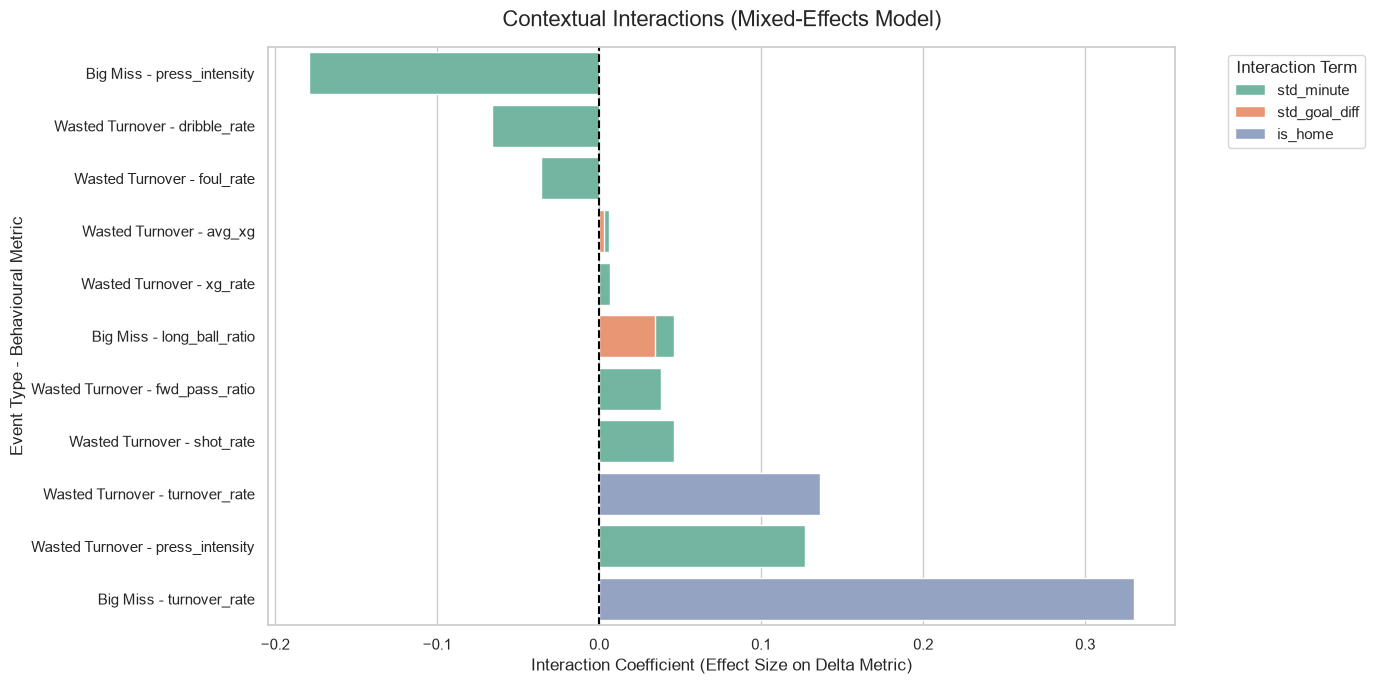

In [9]:
if not summary_df.empty:
    # Prefer FDR-significant interactions for the primary plot.
    plot_df = summary_df[summary_df['fdr_significant_10']].copy()
    
    # Fallback for visualization if no term passes FDR at 10%.
    if plot_df.empty:
        plot_df = summary_df[summary_df['significant_05']].copy()
    
    if not plot_df.empty:
        plot_df['label'] = plot_df['event_type'] + ' - ' + plot_df['metric']
        
        plt.figure(figsize=(14, max(6, len(plot_df) * 0.5)))
        sns.set_theme(style='whitegrid')
        
        sns.barplot(
            data=plot_df.sort_values('coef'),
            x='coef',
            y='label',
            hue='term',
            dodge=False,
            palette='Set2'
        )
        
        plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
        plt.title('Contextual Interactions (Mixed-Effects Model)', fontsize=16, pad=15)
        plt.xlabel('Interaction Coefficient (Effect Size on Delta Metric)', fontsize=12)
        plt.ylabel('Event Type - Behavioural Metric', fontsize=12)
        plt.legend(title='Interaction Term', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig('output/individual/analysis/mixed_effects_plot.png', dpi=300)
        plt.show()
    else:
        print('No interaction is significant at p < 0.05 or FDR q < 0.10.')